In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt 
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import transforms


In [14]:
from torch.utils.data import Dataset, DataLoader
from skimage import io, transform
import os

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

class FaceLandmarksDataset(Dataset):
    def __init__(self, csv_file, img_root_dir, transform=None):
        self.landmarks_frame = []
        file = open(csv_file, "r")
        while True:
            content=file.readline()
            if not content:
                break
            self.landmarks_frame.append(content.split(","))
        file.close()
        self.landmarks_frame = self.landmarks_frame[2:]

        self.img_root_dir = img_root_dir
        self.transform = transform

    def __len__(self):
        return len(self.landmarks_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img_name = os.path.join(self.img_root_dir, self.landmarks_frame[idx][0])
        image = io.imread(img_name)
        landmarks = self.landmarks_frame[idx][1:]
        landmarks = np.array([landmarks], dtype=float).reshape(-1, 2)
        scaled_landmarks = landmarks.copy()
        scaled_landmarks[:, 0], scaled_landmarks[:, 1] = scaled_landmarks[:, 0] / 178, scaled_landmarks[:, 1] / 218
        if self.transform:
            image_tr = self.transform(image)
        scaled_landmarks = scaled_landmarks.reshape(-1)
        sample = {'image': image, 'image_tr':image_tr, 'landmarks': landmarks, 'scaled_landmarks': scaled_landmarks}

        return sample


In [ ]:
full_dataset = FaceLandmarksDataset("/home/gantumur/Documents/DL/Lab456/data/list_landmarks_align_celeba.csv",
                                    "/home/gantumur/Documents/DL/Lab456/data/img_align_celeba/img_align_celeba", transform=transform)

train_val_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_val_size
train_val_set, test_set = torch.utils.data.random_split(full_dataset, [train_val_size, test_size])

train_size = int(0.8 * len(train_val_set))
val_size = len(train_val_set) - train_size
train_set, val_set = torch.utils.data.random_split(train_val_set, [train_size, val_size]) 

In [16]:
sample = train_set[1000]
landmarks = sample['landmarks']
image = sample['image']
print(sample['image_tr'][0,:5,0:5])
print(sample['scaled_landmarks'].shape)

def show_landmarks(image, landmarks):
    """Show image with landmarks"""
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=5, marker='.', c='r')
    plt.pause(0.001)  # pause a bit so that plots are updated

tensor([[0.4196, 0.4235, 0.4196, 0.4078, 0.4039],
        [0.4196, 0.4235, 0.4196, 0.4078, 0.4039],
        [0.4196, 0.4235, 0.4196, 0.4078, 0.4078],
        [0.4196, 0.4235, 0.4196, 0.4118, 0.4078],
        [0.4196, 0.4235, 0.4196, 0.4118, 0.4118]])
(10,)


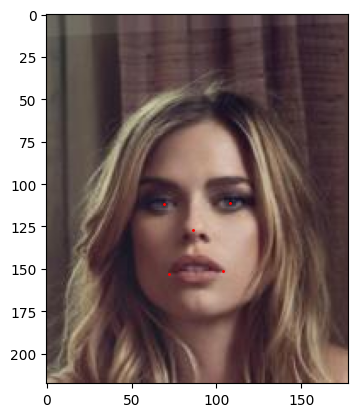

In [17]:
show_landmarks(image, landmarks)

In [18]:
dataloader = DataLoader(train_set, batch_size=8,
                        shuffle=True, num_workers=0)

torch.Size([8, 10]) tensor([[0.3876, 0.5138, 0.6124, 0.5092, 0.4888, 0.6193, 0.4101, 0.6927, 0.5787,
         0.6972],
        [0.3876, 0.5092, 0.6067, 0.5138, 0.4944, 0.6284, 0.4157, 0.6972, 0.5787,
         0.6927],
        [0.3820, 0.5092, 0.6124, 0.5138, 0.4719, 0.6330, 0.3764, 0.6881, 0.6236,
         0.6927],
        [0.3933, 0.5092, 0.6067, 0.5092, 0.5000, 0.5963, 0.4045, 0.7018, 0.5843,
         0.6972],
        [0.3876, 0.5046, 0.6011, 0.5138, 0.4719, 0.6193, 0.4045, 0.6972, 0.5955,
         0.7018],
        [0.3876, 0.5000, 0.5955, 0.5138, 0.5730, 0.5963, 0.4270, 0.6927, 0.5843,
         0.7110],
        [0.3989, 0.4908, 0.5843, 0.5138, 0.5506, 0.5688, 0.4382, 0.7064, 0.5843,
         0.7156],
        [0.3820, 0.5183, 0.6180, 0.5092, 0.5337, 0.6560, 0.3652, 0.6927, 0.6180,
         0.6927]], dtype=torch.float64)


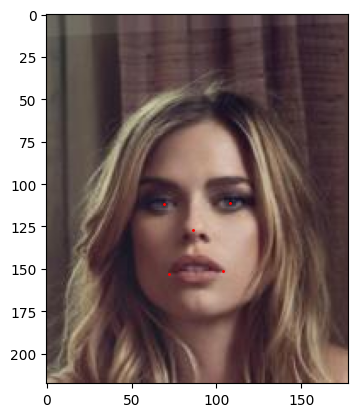

In [19]:
for i in dataloader:
    # print(i[0].shape)
    # landmarks = i[1]
    # image = i[0]
    # print(image, landmarks)
    # break
    print(i['scaled_landmarks'].shape, i['scaled_landmarks'])
    plt.figure()
    show_landmarks(image,
                landmarks)
    plt.show()
    break

# Model 

In [20]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_chanels, **kwargs):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_chanels, **kwargs)
        self.bn = nn.BatchNorm2d(out_chanels)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class InceptionBlock(nn.Module):
    def __init__(self,  in_channels,  out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):

        super(InceptionBlock, self).__init__()
        self.branch1 = ConvBlock(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, red_3x3, kernel_size=1, padding=0),
            ConvBlock(red_3x3, out_3x3, kernel_size=3, padding=1))
        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, red_5x5, kernel_size=1),
            ConvBlock(red_5x5, out_5x5, kernel_size=5, padding=2))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            ConvBlock(in_channels, out_pool, kernel_size=1))

    def forward(self, x):
        branches = (self.branch1, self.branch2, self.branch3, self.branch4)
        return torch.cat([branch(x) for branch in branches], 1)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InceptionAux(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(InceptionAux, self).__init__()
        self.avgpool = nn.AvgPool2d(kernel_size=5, stride=3)
        self.conv = ConvBlock(in_channels, 128, kernel_size=1)
        self.fc1 = nn.Linear(2048, 1024) 
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(p=0.7)

    def forward(self, x):
        x = self.avgpool(x)
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class InceptionModel(nn.Module):
    def __init__(self, aux=False, residual=True, num_classes=1000):
        super(InceptionModel, self).__init__()
        self.aux = aux
        self.residual = residual
        
        self.conv1 = ConvBlock(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.conv2 = ConvBlock(64, 192, kernel_size=3, stride=1, padding=1)

        self.incept3a = InceptionBlock(192, 64, 96, 128, 16, 32, 32) 
        self.incept3b = InceptionBlock(256, 128, 128, 192, 32, 112, 80) 

        self.incept4a = InceptionBlock(512, 192, 96, 208, 16, 48, 64)
        self.incept4b = InceptionBlock(512, 160, 112, 224, 24, 64, 64)

        if self.aux:
            self.aux_classifier = InceptionAux(512, num_classes)

        self.incept5a = InceptionBlock(512, 256, 160, 320, 32, 128, 128) 
        self.incept5b = InceptionBlock(832, 128, 112, 256, 32, 64, 64)         
        
        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(512 * 4 * 4, num_classes)
            
    def forward(self, x):
        
        x = self.conv1(x)
        x = self.maxpool(x)
        
        x = self.conv2(x)
        
        x = self.maxpool(x)
        
        x = self.incept3a(x)
        
        x = self.incept3b(x)
        
        residual = self.maxpool(x)

        x = self.incept4a(residual)
        
        x = self.incept4b(x)
        
        
        if self.residual:
            x += residual 

        if self.aux and self.training:
            aux_out = self.aux_classifier(x)

        residual = self.maxpool(x)

        x = self.incept5a(residual)
        
        x = self.incept5b(x)
        
        if self.residual:
            x += residual

        x = F.adaptive_avg_pool2d(x, (4, 4))
        
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(x)
        x = self.fc(x)

        if self.aux and self.training:
            return x, aux_out
        return x

In [26]:
dummy_input = torch.rand(8,3,218,178)
print(dummy_input.shape)

torch.Size([8, 3, 218, 178])


In [27]:
net = InceptionModel(num_classes=40)
out = net(dummy_input)

print(out.shape)

torch.Size([8, 40])


In [28]:
net 

InceptionModel(
  (conv1): ConvBlock(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv2): ConvBlock(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (incept3a): InceptionBlock(
    (branch1): ConvBlock(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (branch2): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ConvBlock(
        (conv): Conv2d(96, 128, kernel_size=(3, 

In [30]:
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=16,
    shuffle=True
)



In [31]:
batch_dict = next(iter(train_loader))

X_single_batch = batch_dict["image_tr"]
y_single_batch = batch_dict["scaled_landmarks"]



In [ ]:
import torch.optim as optim 
import itertools 


learning_rates = [1e-3, 5e-4, 1e-4]
optimizers = ["Adam", "SGD_Momentum"]

loss_functions = {
    "MSE": nn.MSELoss(),
    "SmoothL1": nn.SmoothL1Loss()
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

X_single_batch = X_single_batch.to(device)
y_single_batch = y_single_batch.to(device)

epochs_per_test = 50 
best_loss = float("-inf")
best_combo = None

for lr, opt_name, loss_name in itertools.product(learning_rates, optimizers, loss_functions):
    model = InceptionModel(aux=True, residual=True, num_classes=10).to(device)
    model.train()

    if opt_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    criterion = loss_functions[loss_name]
    aux_weight = 0.3
    final_loss = 0.0 

    for epoch in range(epochs_per_test):
        optimizer.zero_grad()
        main_out, aux_out = model(X_single_batch)

        loss_main = criterion(main_out, y_single_batch)
        loss_aux = criterion(aux_out, y_single_batch)

        total_loss = loss_main + (aux_weight * loss_aux)

        total_loss.backward()
        optimizer.step()
        
        final_loss = total_loss.item()
    print(
        f"Tested: LR={lr}, Opt={opt_name}, Loss={loss_name} | Final Loss: {final_loss:.6f}")

    if final_loss < best_loss:
        best_loss = final_loss
        best_combo = {'LR': lr, 'Optimizer': opt_name, 'Loss': loss_name}

    del model
    del optimizer
    torch.cuda.empty_cache()

print(f"Best Combination Found: {best_combo}")
print(f"Lowest Loss Achieved: {best_loss:.6f}")

Running on: cuda


RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x1536 and 2048x1024)